# 1. Import Required Libraries 

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
from mplsoccer import Pitch, Sbopen

# 2. Load the Dataset 

In [2]:
parser = Sbopen()
df, related, freeze, tactics = parser.event(3923881) #afcon 2023 

## 2.1 Preparing the Data  

For passing networks we use only accurate/succesful passes made by a team unitl the first sub. 
This is mainly to get going and there are several possible variations to this. 

We need info about the pass start and end locations as well as the players involved:

In [3]:
#check for index of 1st sub.
sub = df.loc[df["type_name"] == "Substitution"].loc[df["team_name"] == "Côte d'Ivoire"].iloc[0]["index"]

#make dataframe with successfull passes made by Ivory Coast until the 1st sub.
mask_ivory_coast = (df.type_name == 'Pass') & (df.team_name == "Côte d'Ivoire") & (df.index < sub) & (df.outcome_name.isnull()) & (df.sub_type_name != "Throw-in")

#take the required columns
df_pass = df.loc[mask_ivory_coast, ['x', 'y', 'end_x', 'end_y', "player_name", "pass_recipient_name"]]

#Select only the player's surname
df_pass["player_name"] = df_pass["player_name"].apply(lambda x: str(x).split()[-1])
df_pass["pass_recipient_name"] = df_pass["pass_recipient_name"].apply(lambda x: str(x).split()[-1])

## 2.2 Calculating Vertices Size and Location 

First, create an empty dataframe. For each player calculate the average location of passes made and receptions. 
Then, calculate the number of passes made by each player. Lastly, set the marker size to be proportional to number of passes:

In [4]:
scatter_df = pd.DataFrame()
for i, name in enumerate(df_pass["player_name"].unique()):
    pass_x = df_pass.loc[df_pass["player_name"] == name]["x"].to_numpy()
    rec_x = df_pass.loc[df_pass["pass_recipient_name"] == name]["end_x"].to_numpy()
    pass_y = df_pass.loc[df_pass["player_name"] == name]["y"].to_numpy()
    rec_y = df_pass.loc[df_pass["pass_recipient_name"] == name]["end_y"].to_numpy()
    scatter_df.at[i, "player_name"] = name
    
    #make sure that x and y location for each circle representing the player is the average of passes and receptions
    scatter_df.at[i, "x"] = np.mean(np.concatenate([pass_x, rec_x]))
    scatter_df.at[i, "y"] = np.mean(np.concatenate([pass_y, rec_y]))
   
    #calculate No. of passes
    scatter_df.at[i, "no"] = df_pass.loc[df_pass["player_name"] == name].count().iloc[0]

#adjust the size of a circle so that the player who made more passes
scatter_df['marker_size'] = (scatter_df['no'] / scatter_df['no'].max() * 1500)

# 2.3 Calculating the Width of Edges

To calculate edge width, look at the No. of passes between players. Group the dataframe of passes by combining passer and recepient, and count passes between them. 

Lastly, set the threshold by ignoring players that made fewer than two passes:

In [5]:
#Count the passes between players 
df_pass["pair_key"] = df_pass.apply(lambda x: "_".join(sorted([x["player_name"], x["pass_recipient_name"]])), axis=1)
lines_df = df_pass.groupby(["pair_key"]).x.count().reset_index()
lines_df.rename({'x':'pass_count'}, axis='columns', inplace=True)

#Set a threshold
lines_df = lines_df[lines_df['pass_count']>2]

# 2.4 Plotting Vertices 

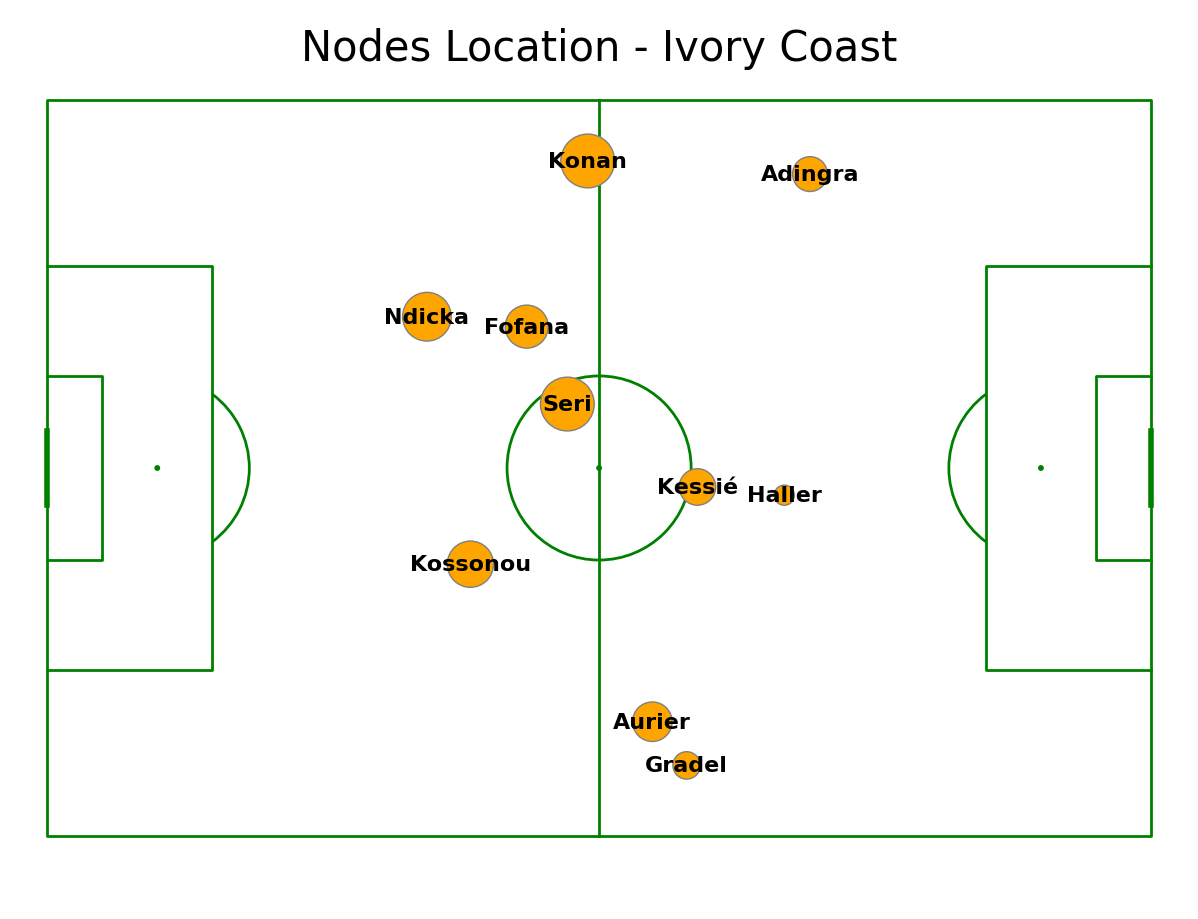

In [6]:
#Draw the Pitch 
pitch = Pitch(line_color='green')
fig, ax = pitch.grid(grid_height=0.9, title_height=0.06, axis=False,
                     endnote_height=0.04, title_space=0, endnote_space=0)

#Scatter the location on the pitch
pitch.scatter(scatter_df.x, scatter_df.y, s=scatter_df.marker_size, color='orange', edgecolors='grey', linewidth=1, alpha=1, ax=ax["pitch"], zorder = 3)

#annotate player name
for i, row in scatter_df.iterrows():
    pitch.annotate(row.player_name, xy=(row.x, row.y), c='black', va='center', ha='center', weight = "bold", size=16, ax=ax["pitch"], zorder = 4)

fig.suptitle("Nodes Location - Ivory Coast", fontsize = 30)
plt.show()

# 2.5 Plotting Edges 

For each combination of players who made passes, make a query to scatter_df to get the start and end of the line. 
Then, adjust the line width so that the more passes between the players, the wider the line. Lastly, plot the lines on the pitch. 

Please Note: the zorder of edges should be lower than zorder of vertioces:

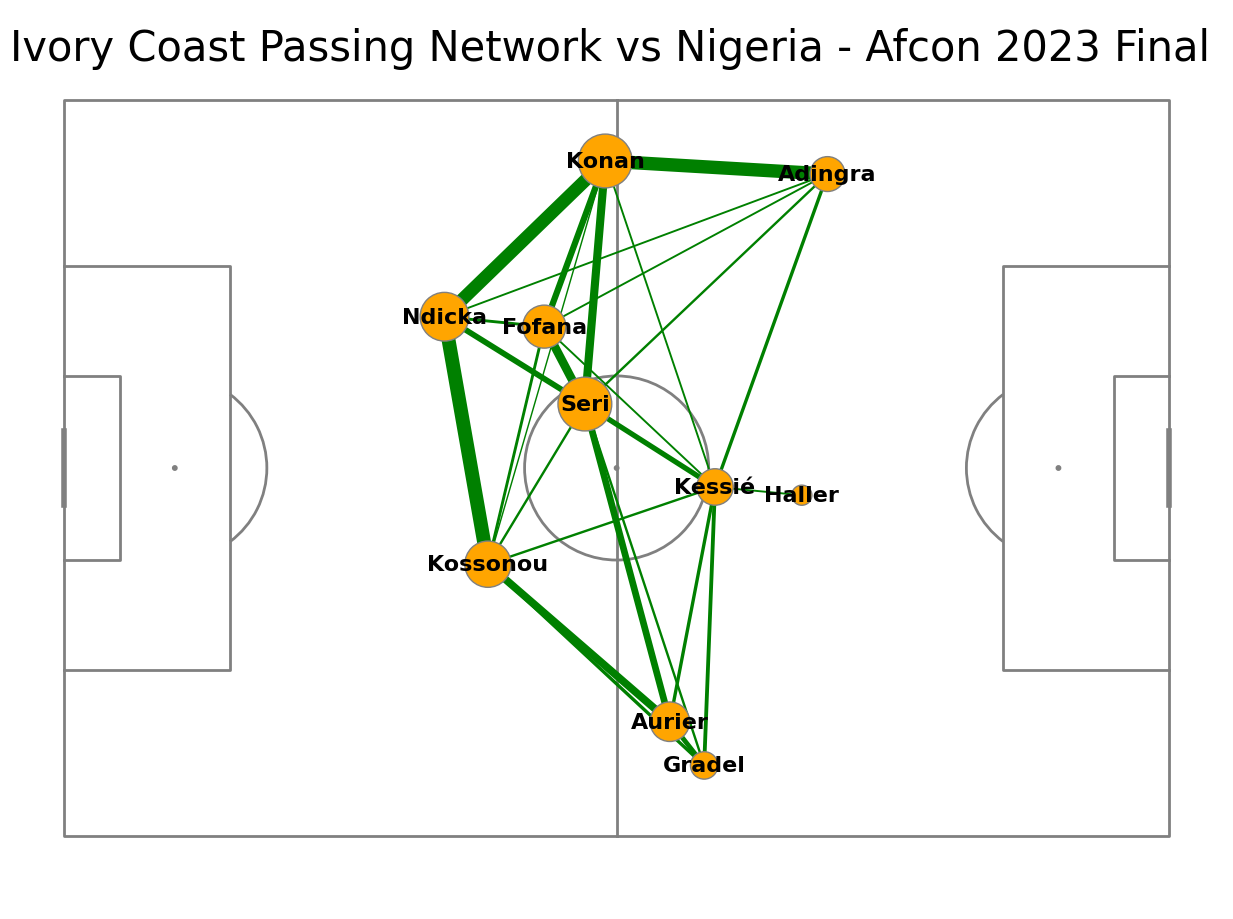

In [7]:
#plot once again pitch and vertices
pitch = Pitch(line_color='grey')
fig, ax = pitch.grid(grid_height=0.9, title_height=0.06, axis=False,
                     endnote_height=0.04, title_space=0, endnote_space=0)

pitch.scatter(scatter_df.x, scatter_df.y, s=scatter_df.marker_size, color='orange', edgecolors='grey', linewidth=1, alpha=1, ax=ax["pitch"], zorder = 3)
for i, row in scatter_df.iterrows():
    pitch.annotate(row.player_name, xy=(row.x, row.y), c='black', va='center', ha='center', weight = "bold", size=16, ax=ax["pitch"], zorder = 4)

for i, row in lines_df.iterrows():
        player1 = row["pair_key"].split("_")[0]
        player2 = row['pair_key'].split("_")[1]
        #take the average location of players to plot a line between them
        player1_x = scatter_df.loc[scatter_df["player_name"] == player1]['x'].iloc[0]
        player1_y = scatter_df.loc[scatter_df["player_name"] == player1]['y'].iloc[0]
        player2_x = scatter_df.loc[scatter_df["player_name"] == player2]['x'].iloc[0]
        player2_y = scatter_df.loc[scatter_df["player_name"] == player2]['y'].iloc[0]
        num_passes = row["pass_count"]
        #adjust the line width so that the more passes, the wider the line
        line_width = (num_passes / lines_df['pass_count'].max() * 10)
        #plot lines on the pitch
        pitch.lines(player1_x, player1_y, player2_x, player2_y,
                        alpha=1, lw=line_width, zorder=2, color="green", ax = ax["pitch"])

fig.suptitle("Ivory Coast Passing Network vs Nigeria - Afcon 2023 Final ", fontsize = 30)
plt.show()

# 3. Calculating Centralisation 

To find the centralisation index we need to calculate the number of passes made by each player.

Then, we calculate the denominator: i.e., the sum of all passes multiplied by(No. of players - 1) -> 10. 

To calculate the numerator we sum the diffrence between maximal No. of succesful passes by 1 player and No. of successful passes by each player. 

We calcuulate the index by dividing the numerator by the denominator:

In [8]:
#calculate number of successful passes by player
no_passes = df_pass.groupby(['player_name']).x.count().reset_index()
no_passes.rename({'x':'pass_count'}, axis='columns', inplace=True)

#find one who made most passes
max_no = no_passes["pass_count"].max()

#calculate the denominator - 10*the total sum of passes
denominator = 10*no_passes["pass_count"].sum()

#calculate the nominator
nominator = (max_no - no_passes["pass_count"]).sum()

#calculate the centralisation index
centralisation_index = nominator/denominator
print("Centralisation index is ", centralisation_index)

Centralisation index is  0.06611295681063123
